# Particle Classification on Cytoplasmic Tracking Data

End-to-end training and evaluation of a graph neural network for classifying intracellular particle trajectories. Detections are represented as graph nodes, candidate temporal links as edges, and each trajectory graph is classified into a particle type using a global message-passing model.

In [1]:
import os
import subprocess

repo_root = subprocess.check_output(["git", "rev-parse", "--show-toplevel"]).decode().strip()
os.chdir(repo_root)

In [2]:
import deeplay as dl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from lightning.pytorch.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from torch_geometric.loader import DataLoader
from torchvision.transforms import Compose

from trajan.custom_models.magik import MagikMPM
from trajan.data import TracksDataFrame
from trajan.dataset import VelocityGraphDataset
from trajan.graph import VelocityGraphFromTrajectories
from trajan.transforms import RandomFlip, RandomRotation
from trajan.visualization import plot_confusion_matrix

## Data

Load the cytoplasmic tracking dataset and split into train/validation sets. Each row is a single particle detection; trajectories are grouped by `label` within each recording (`set`). The connectivity radius and trajectory span std are estimated from the training set only.

In [3]:
tracks_path = os.path.join("data", "cytoplasmic", "tracks.csv")

data = pd.read_csv(tracks_path, skiprows=1)
data = TracksDataFrame(data, frame_rate=10)

data_description = data.describe_tracks()
display_labels = data_description["particle_types"]

particle_types: ['endosome', 'golgi', 'postgolgi']
frame_rate: 10

endosome:
  n_recordings: 20
  recording_ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  n_tracks: 339
  avg_track_len: 130.65

golgi:
  n_recordings: 7
  recording_ids: [20, 21, 22, 23, 24, 25, 26]
  n_tracks: 103
  avg_track_len: 142.37

postgolgi:
  n_recordings: 11
  recording_ids: [27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
  n_tracks: 131
  avg_track_len: 131.94


## Graph Construction

Build a graph from each trajectory: nodes are detections, directed edges connect detections that are within `connectivity_radius` spatially and at most `max_frame_distance` frames apart. Edge features encode normalized distance, normalized frame gap, and a motion energy proxy.

In [4]:
test_size = 0.25
seed = 6
Dt_range = (50, 120)
max_frame_gap = 3

train_data, val_data = data.split_train_test(test_size=test_size, seed=seed)

graph_builder, velocity_std = VelocityGraphFromTrajectories.from_tracks(
    train_data, max_frame_gap, frame_rate=10
)

train_graphs = graph_builder(train_data, target_column="type", split_tracks=True)
val_graphs = graph_builder(val_data, target_column="type", split_tracks=True)

In [5]:
transform = Compose([RandomRotation(), RandomFlip()])

train_dataset_size = 2 * int(sum(len(g.x) for g in train_graphs) / np.mean(Dt_range))
val_dataset_size = 5 * int(sum(len(g.x) for g in val_graphs) / np.mean(Dt_range))
train_batch_size = 16
val_batch_size = 256

train_dataset = VelocityGraphDataset(
    train_graphs,
    Dt_range,
    train_dataset_size,
    velocity_std,
    transform=transform,
    target="global",
    sample_balanced=True,
)
val_dataset = VelocityGraphDataset(
    val_graphs,
    Dt_range,
    val_dataset_size,
    velocity_std,
    target="global",
)

train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch_size,
    shuffle=True,
    num_workers=0,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=val_batch_size,
    num_workers=0,
)

## Feature Distributions

Inspect node position and edge feature distributions across the full dataset after normalization. Each sample is a random `Dt`-frame subgraph, so positions are centred per subgraph.

In [6]:
# feature and position distribution
all_graphs = train_graphs + val_graphs
full_dataset_size = int(sum(len(g.x) for g in all_graphs) / np.mean(Dt_range))

full_dataset = VelocityGraphDataset(
    all_graphs,
    Dt_range,
    full_dataset_size,
    velocity_std,
    target='global',
)

full_data_loader = DataLoader(
    full_dataset,
    batch_size=1
)

keys = ['x', 'edge_attr', 'local_scale', 'persistence', 'y']
collected = {key: [] for key in keys}

for graph in full_data_loader:
    for key in keys:
        collected[key].append(getattr(graph, key))

pos           = torch.vstack(collected['x']).numpy()
edge_attr     = torch.vstack(collected['edge_attr']).numpy()
local_scale   = torch.vstack(collected['local_scale']).numpy().squeeze()
persistence   = torch.vstack(collected['persistence']).numpy().squeeze()
labels        = torch.vstack(collected['y']).numpy().squeeze()

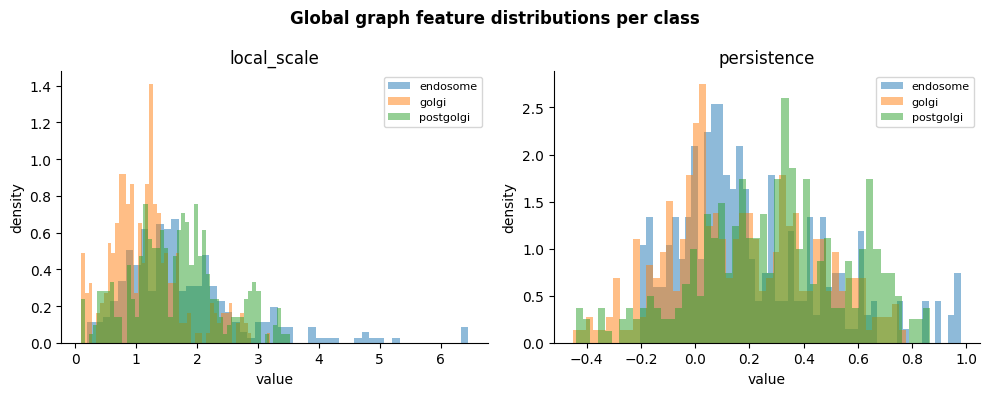

In [7]:
features_to_plot = {
    'local_scale': local_scale,
    'persistence': persistence,
}

label_names = {i: name for i, name in enumerate(display_labels)}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (feat_name, feat_vals) in zip(axes, features_to_plot.items()):
    for label_idx, label_name in label_names.items():
        mask = labels == label_idx
        ax.hist(feat_vals[mask], bins=50, alpha=0.5, density=True, label=label_name)
    ax.set_title(feat_name)
    ax.set_xlabel('value')
    ax.set_ylabel('density')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Global graph feature distributions per class', fontweight='bold')
plt.tight_layout()
plt.savefig("global_features_gcn")

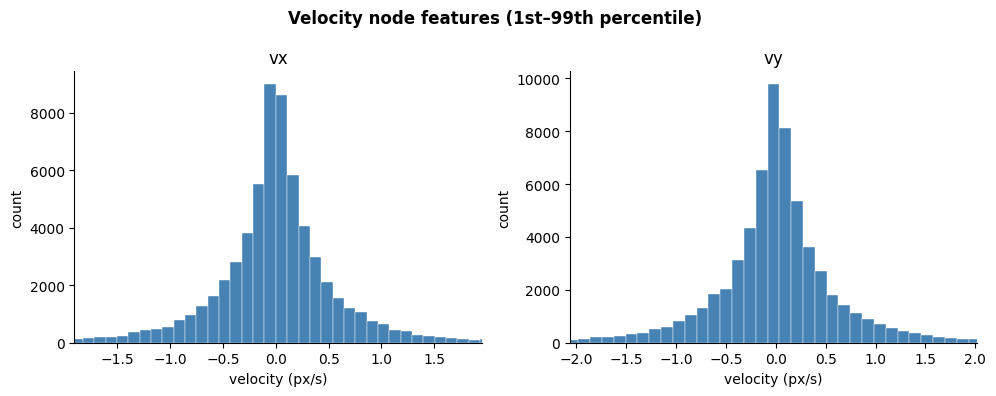

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, data, label in zip(axes, [pos[:, 0], pos[:, 1]], ['vx', 'vy']):
    ax.hist(data, bins=100, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_xlim(np.percentile(data, 1), np.percentile(data, 99))
    ax.set_title(label)
    ax.set_xlabel('velocity (px/s)')
    ax.set_ylabel('count')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Velocity node features (1st–99th percentile)', fontweight='bold')
plt.tight_layout()
plt.savefig("velocities_gcn")

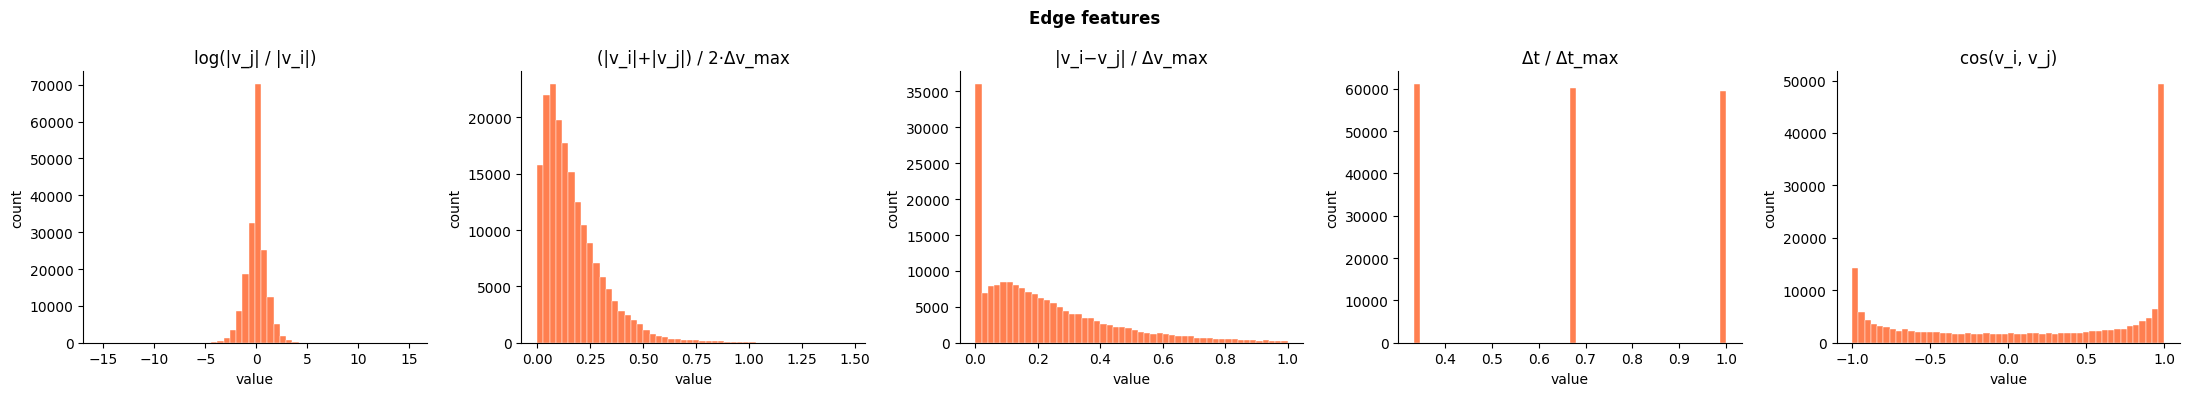

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

edge_labels = [
    'log(|v_j| / |v_i|)',
    '(|v_i|+|v_j|) / 2·Δv_max',
    '|v_i−v_j| / Δv_max',
    'Δt / Δt_max',
    'cos(v_i, v_j)',
]
for ax, data, label in zip(axes, [edge_attr[:, i] for i in range(5)], edge_labels):
    ax.hist(data, bins=50, color='coral', edgecolor='white', linewidth=0.3)
    ax.set_title(label)
    ax.set_xlabel('value')
    ax.set_ylabel('count')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Edge features', fontweight='bold')
plt.tight_layout()
plt.savefig("edge_features_gcn")

## Model

Graph-to-global message-passing network (`GraphToGlobalMPM`): encodes node and edge features independently, runs `num_blocks` message-passing steps, mean-pools to a graph-level embedding, and outputs a class probability vector via a small MLP head.

In [11]:
encoder_dimension = 96
num_blocks = 4
num_classes = 3
lr = 1e-4
wd = 1e-5

# labels = np.array([g.graph_label.item() for g in train_graphs])
# counts = np.bincount(labels, minlength=num_classes).astype(float)
# class_weights = torch.tensor(len(labels) / (num_classes * counts), dtype=torch.float)
# loss_fn = nn.CrossEntropyLoss(weight=class_weights)

loss_fn = nn.CrossEntropyLoss()

magik = MagikMPM(
    [encoder_dimension] * num_blocks,
    out_activation=nn.Softmax(dim=1),
    out_features=num_classes,
)

magik.head.configure(in_features=encoder_dimension+2, out_features=num_classes)

model = dl.CategoricalClassifier(
    model=magik,
    optimizer=dl.Adam(
        lr=lr,
        weight_decay=wd,
    ),
    loss=loss_fn,
    num_classes=num_classes,
).build()

In [12]:
# uncomment to store best model

# run_name = f"dim{encoder_dimension}_blocks{num_blocks}_Dt{Dt}"
# run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
# run_dir = os.path.join("runs", "example", run_name, run_id)
# os.makedirs(run_dir, exist_ok=True)

# checkpoint_cb = ModelCheckpoint(
#     dirpath=run_dir,
#     filename="best",
#     monitor="val_loss",
#     mode="min",
#     save_top_k=1,
# )

run_dir = os.path.join(repo_root, "notebooks", "runs")

checkpoint_cb = ModelCheckpoint(
    dirpath=run_dir,
    monitor="val_loss",
    mode="min",
    save_top_k=1,
)

callbacks = [checkpoint_cb]

## Training

In [14]:
num_epochs = 15

trainer = dl.Trainer(
    max_epochs=num_epochs,
    accelerator="auto",
    callbacks=callbacks,
)

trainer.fit(model, train_loader, val_loader)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ CrossEntropyLoss │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ MagikMPM         │  191 K │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 75                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

1.0755759477615356


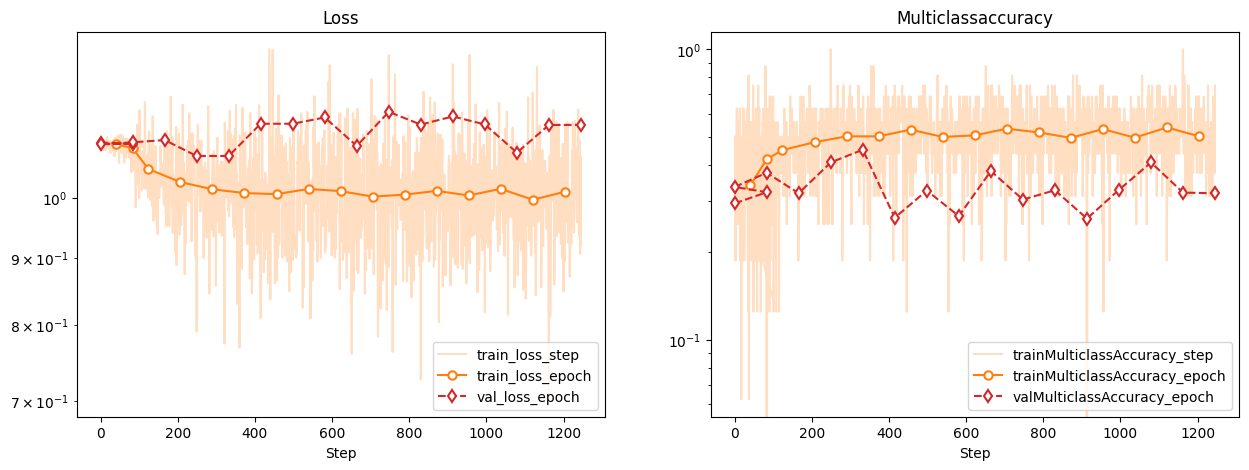

In [15]:
fig, ax = trainer.history.plot()
# fig.savefig(run_dir / "training_curves.png")

best_val_loss = checkpoint_cb.best_model_score.item() if checkpoint_cb.best_model_score is not None else float("inf")
print(best_val_loss)

## Evaluation

Load the best checkpoint and evaluate on the validation set.

In [16]:
best_model = dl.CategoricalClassifier.load_from_checkpoint(
    checkpoint_cb.best_model_path
)
best_model.eval()

CategoricalClassifier(
  (loss): CrossEntropyLoss()
  (train_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=test
  )
  (model): MagikMPM(
    (encoder): Parallel(
      (0-1): 2 x MultiLayerPerceptron(
        (blocks): LayerList(
          (0): LinearBlock(
            (layer): LazyLinear(in_features=0, out_features=96, bias=True)
            (activation): Identity()
          )
        )
      )
    )
    (backbone): MessagePassingNeuralNetwork(
      (blocks): LayerList(
        (0-3): 4 x TransformPropagateUpdate(
          (transform): Transform(
            (combine): Cat()
            (layer): LazyLinear(in_features=0, out_features=96, bias=True)
            (activation): ReLU()
          )
          (propagate): Sum()
          (update

              precision    recall  f1-score   support

    endosome       0.07      0.03      0.05       381
       golgi       0.45      0.72      0.55       381
   postgolgi       0.45      0.40      0.42       393

    accuracy                           0.39      1155
   macro avg       0.32      0.39      0.34      1155
weighted avg       0.32      0.39      0.34      1155



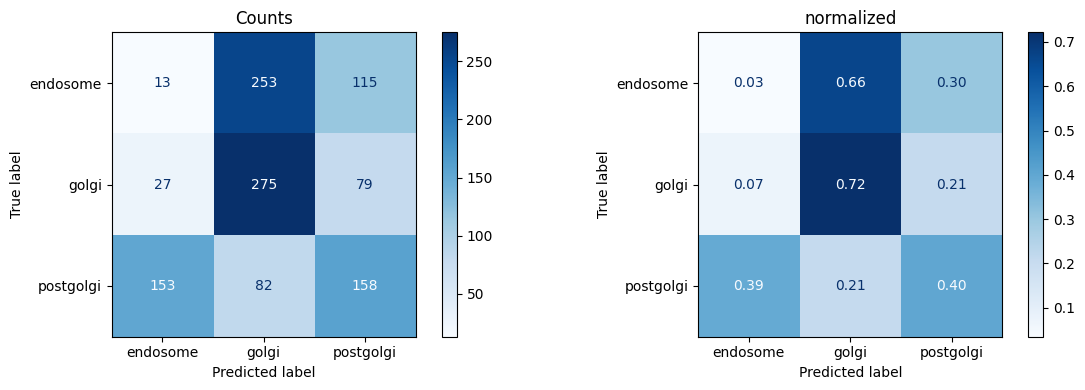

In [17]:
truth, preds = [], []
with torch.no_grad():
    for batch in val_loader:
        y_pred = torch.argmax(best_model(batch), dim=1)
        truth.append(batch.y)
        preds.append(y_pred)

truth = torch.concat(truth).numpy()
preds = torch.concat(preds).numpy()

# Classification report
report = classification_report(truth, preds, target_names=display_labels)
print(report)

# Confusion Matrix
cm = confusion_matrix(truth, preds)
cm_df = pd.DataFrame(cm, index=display_labels, columns=display_labels)

fig = plot_confusion_matrix(cm_df, display_labels)
plt.show(fig)

              precision    recall  f1-score   support

    endosome       0.49      0.22      0.30       435
       golgi       0.53      0.80      0.64       449
   postgolgi       0.48      0.50      0.49       432

    accuracy                           0.51      1316
   macro avg       0.50      0.50      0.48      1316
weighted avg       0.50      0.51      0.48      1316



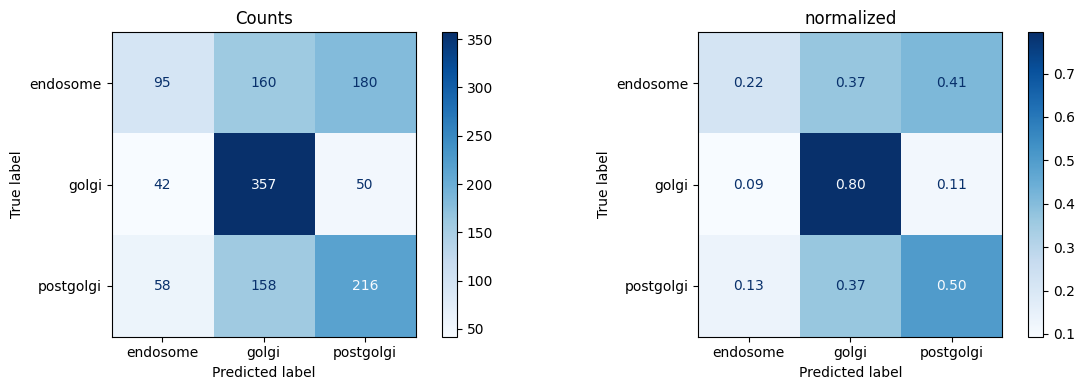

In [18]:
truth, preds = [], []
with torch.no_grad():
    for batch in train_loader:
        y_pred = torch.argmax(best_model(batch), dim=1)
        truth.append(batch.y)
        preds.append(y_pred)

truth = torch.concat(truth).numpy()
preds = torch.concat(preds).numpy()

# Classification report
report = classification_report(truth, preds, target_names=display_labels)
print(report)

# Confusion Matrix
cm = confusion_matrix(truth, preds)
cm_df = pd.DataFrame(cm, index=display_labels, columns=display_labels)

fig = plot_confusion_matrix(cm_df, display_labels)
plt.show(fig)

In [16]:
import shutil
shutil.rmtree(run_dir)